In [1]:
# -----------------------------------------
# 1. Import required libraries
# -----------------------------------------
import pandas as pd
import numpy as np

# -----------------------------------------
# 2. Load dataset
# -----------------------------------------
file_path = "/content/diabetes_012_health_indicators_BRFSS2015.csv"

df = pd.read_csv(file_path)

# -----------------------------------------
# 3. Basic information
# -----------------------------------------
print("Shape of the dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("\nDataset Info:")
print(df.info())

# -----------------------------------------
# 4. Display first 5 rows
# -----------------------------------------
print("\nFirst 5 rows:")
display(df.head())

# -----------------------------------------
# 5. Summary statistics (numerical features)
# -----------------------------------------
print("\nSummary Statistics:")
display(df.describe().T)

# -----------------------------------------
# 6. Check missing values
# -----------------------------------------
print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------------------
# 7. Check data types
# -----------------------------------------
print("\nData Types:")
print(df.dtypes)

# -----------------------------------------
# 8. Basic distribution of target variable (if target exists)
# -----------------------------------------
if "Diabetes_012" in df.columns:
    print("\nTarget Variable Distribution:")
    print(df["Diabetes_012"].value_counts())


Shape of the dataset: (253680, 22)

Column names:
 ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   Diabetes_012          253680 non-null  int64
 1   HighBP                253680 non-null  int64
 2   HighChol              253680 non-null  int64
 3   CholCheck             253680 non-null  int64
 4   BMI                   253680 non-null  int64
 5   Smoker                253680 non-null  int64
 6   Stroke                253680 non-null  int64
 7   HeartDiseaseorAttack  253680 non-null  int64
 8   PhysActivity          253680 non-null  in

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4



Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0



Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Data Types:
Diabetes_012            int64
HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           i

In [2]:
# Minimal EDA + save outputs for report
# Run in Colab. Assumes file is at: /content/diabetes_012_health_indicators_BRFSS2015.csv

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile

# -----------------------------
# Settings
# -----------------------------
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
OUT_DIR = Path("/content/eda")
RANDOM_STATE = 42

# Create output dir
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "plots").mkdir(exist_ok=True)
(OUT_DIR / "tables").mkdir(exist_ok=True)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)

# -----------------------------
# Create binary target
# -----------------------------
# 0 -> healthy, 1 -> pre-diabetes or diabetes (1 or 2)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)

# Save sample and head
df.head(10).to_csv(OUT_DIR / "tables" / "head_sample.csv", index=False)
df.sample(100, random_state=RANDOM_STATE).to_csv(OUT_DIR / "tables" / "random_sample_100.csv", index=False)

# -----------------------------
# Summary tables (CSV)
# -----------------------------
# 1) Full descriptive stats
desc = df.describe(include="all").T
desc.to_csv(OUT_DIR / "tables" / "describe_all.csv")

# 2) Missing values (should be none but save to file)
missing = df.isnull().sum().rename("missing_count").to_frame()
missing.to_csv(OUT_DIR / "tables" / "missing_values.csv")

# 3) Original target distribution and binary target distribution
orig_counts = df["Diabetes_012"].value_counts().rename_axis("Diabetes_012").reset_index(name="count")
orig_counts.to_csv(OUT_DIR / "tables" / "orig_target_counts.csv", index=False)

bin_counts = df["Diabetes_binary"].value_counts().rename_axis("Diabetes_binary").reset_index(name="count")
bin_counts.to_csv(OUT_DIR / "tables" / "binary_target_counts.csv", index=False)

# 4) Class-wise summary (means, medians) for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# remove Diabetes_012 (original) and Diabetes_binary from numeric summary if desired
numeric_cols_for_summary = [c for c in numeric_cols if c not in ["Diabetes_012"]]
classwise_means = df.groupby("Diabetes_binary")[numeric_cols_for_summary].agg(["count","mean","median","std"])
# Flatten columns
classwise_means.columns = ['_'.join(col).strip() for col in classwise_means.columns.values]
classwise_means.reset_index().to_csv(OUT_DIR / "tables" / "classwise_summary.csv", index=False)

# 5) Correlation matrix and save as CSV
corr = df[numeric_cols_for_summary].corr()
corr.to_csv(OUT_DIR / "tables" / "correlation_matrix.csv")

# -----------------------------
# Quick plots to save
# -----------------------------
plt.rcParams.update({'figure.max_open_warning': 0})

# function to save histograms for a list of columns
def save_histograms(columns, bins=30, outdir=OUT_DIR/"plots"):
    for col in columns:
        try:
            plt.figure(figsize=(6,4))
            df[col].hist(bins=bins)
            plt.title(f"Histogram: {col}")
            plt.xlabel(col)
            plt.ylabel("count")
            plt.tight_layout()
            plt.savefig(outdir / f"hist_{col}.png", dpi=150)
            plt.close()
        except Exception as e:
            print("Hist error:", col, e)

# function to save boxplots for a list of columns (by class)
def save_boxplots(columns, outdir=OUT_DIR/"plots"):
    for col in columns:
        try:
            plt.figure(figsize=(6,4))
            df.boxplot(column=col, by="Diabetes_binary")
            plt.suptitle("")  # remove default suptitle
            plt.title(f"Boxplot of {col} by Diabetes_binary")
            plt.xlabel("Diabetes_binary")
            plt.ylabel(col)
            plt.tight_layout()
            plt.savefig(outdir / f"box_{col}_by_class.png", dpi=150)
            plt.close()
        except Exception as e:
            print("Boxplot error:", col, e)

# Select columns for histogram/boxplot (continuous-ish)
cont_cols = ["BMI", "MentHlth", "PhysHlth", "Age", "GenHlth"]
save_histograms(cont_cols)
save_boxplots(cont_cols)

# Plot class-wise bar charts for selected binary/categorical-like features
cat_like = ["HighBP","HighChol","Smoker","Stroke","HeartDiseaseorAttack","PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare","NoDocbcCost","DiffWalk","Sex","Education","Income","CholCheck"]
for col in cat_like:
    try:
        ct = pd.crosstab(df[col], df["Diabetes_binary"])
        ax = ct.plot(kind="bar", figsize=(6,4))
        plt.title(f"{col} by Diabetes_binary (counts)")
        plt.xlabel(col)
        plt.ylabel("count")
        plt.tight_layout()
        fname = OUT_DIR / "plots" / f"bar_{col}_by_class.png"
        plt.savefig(fname, dpi=150)
        plt.close()
    except Exception as e:
        print("Bar plot error:", col, e)

# Correlation heatmap (matplotlib)
try:
    plt.figure(figsize=(10,9))
    im = plt.imshow(corr, interpolation='none', aspect='auto')
    plt.colorbar(im, fraction=0.03, pad=0.04)
    ticks = np.arange(len(corr.columns))
    plt.xticks(ticks, corr.columns, rotation=90, fontsize=8)
    plt.yticks(ticks, corr.columns, fontsize=8)
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "plots" / "correlation_heatmap.png", dpi=200)
    plt.close()
except Exception as e:
    print("Heatmap error:", e)

# Save a small table of top correlations with target (absolute)
try:
    target_corr = corr["Diabetes_binary"].abs().sort_values(ascending=False)
    target_corr.to_csv(OUT_DIR / "tables" / "correlation_with_target_abs.csv", header=True)
except Exception as e:
    print("Target corr save error:", e)

# -----------------------------
# Save a short textual summary to file
# -----------------------------
summary_text = []
summary_text.append(f"Dataset shape: {df.shape}")
summary_text.append("\nOriginal target distribution:\n" + orig_counts.to_string(index=False))
summary_text.append("\nBinary target distribution:\n" + bin_counts.to_string(index=False))
summary_text.append("\nSelected continuous columns analyzed: " + ", ".join(cont_cols))
summary_text.append("\nNumeric columns used in correlation: " + ", ".join(numeric_cols_for_summary))
# write text file
with open(OUT_DIR / "tables" / "eda_summary.txt", "w") as f:
    f.write("\n\n".join(summary_text))

# -----------------------------
# Zip outputs for convenience
# -----------------------------
zipf = "/content/eda_results.zip"
with zipfile.ZipFile(zipf, 'w', zipfile.ZIP_DEFLATED) as zf:
    # add tables
    for fn in (OUT_DIR/"tables").glob("*"):
        zf.write(fn, arcname=f"tables/{fn.name}")
    # add plots
    for fn in (OUT_DIR/"plots").glob("*"):
        zf.write(fn, arcname=f"plots/{fn.name}")

print("All EDA outputs saved to:", OUT_DIR)
print("Zipped output at:", zipf)

# Optionally list files saved (small)
for p in sorted(list((OUT_DIR/"tables").glob("*")) + list((OUT_DIR/"plots").glob("*")) )[:30]:
    print("-", p.name)

# If you want, provide a small preview of class-wise means
display(classwise_means.head())


Loaded: (253680, 22)
All EDA outputs saved to: /content/eda
Zipped output at: /content/eda_results.zip
- bar_AnyHealthcare_by_class.png
- bar_CholCheck_by_class.png
- bar_DiffWalk_by_class.png
- bar_Education_by_class.png
- bar_Fruits_by_class.png
- bar_HeartDiseaseorAttack_by_class.png
- bar_HighBP_by_class.png
- bar_HighChol_by_class.png
- bar_HvyAlcoholConsump_by_class.png
- bar_Income_by_class.png
- bar_NoDocbcCost_by_class.png
- bar_PhysActivity_by_class.png
- bar_Sex_by_class.png
- bar_Smoker_by_class.png
- bar_Stroke_by_class.png
- bar_Veggies_by_class.png
- box_Age_by_class.png
- box_BMI_by_class.png
- box_GenHlth_by_class.png
- box_MentHlth_by_class.png
- box_PhysHlth_by_class.png
- correlation_heatmap.png
- hist_Age.png
- hist_BMI.png
- hist_GenHlth.png
- hist_MentHlth.png
- hist_PhysHlth.png
- binary_target_counts.csv
- classwise_summary.csv
- correlation_matrix.csv


,HighBP_count,HighBP_mean,HighBP_median,HighBP_std,HighChol_count,HighChol_mean,HighChol_median,HighChol_std,CholCheck_count,CholCheck_mean,...,Education_median,Education_std,Income_count,Income_mean,Income_median,Income_std,Diabetes_binary_count,Diabetes_binary_mean,Diabetes_binary_median,Diabetes_binary_std
Diabetes_binary,,,,,,,,,,,,,,,,,,,,,
0,213703,0.371132,0.0,0.483109,213703,0.379171,0.0,0.485182,213703,0.957104,...,5.0,0.960423,213703,6.208663,7.0,2.005203,213703,0.0,0.0,0.0
1,39977,0.738350,1.0,0.439539,39977,0.664407,1.0,0.472203,39977,0.992421,...,5.0,1.062263,39977,5.226430,6.0,2.216756,39977,1.0,1.0,0.0


<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [3]:
from google.colab import files
files.download('/content/eda_results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# --------------------------------------
# STEP 2: BINARY MODELING SETUP + BASELINE LOGISTIC REGRESSION
# --------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from pathlib import Path
import joblib

# -----------------------------
# LOAD DATA
# -----------------------------
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")

# -----------------------------
# CREATE BINARY TARGET
# -----------------------------
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)

# -----------------------------
# FEATURES & TARGET
# -----------------------------
X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]

# -----------------------------
# TRAIN-TEST SPLIT (STRATIFIED)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# -----------------------------
# CLASS IMBALANCE: CALCULATE scale_pos_weight FOR XGBOOST
# -----------------------------
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight =", scale_pos_weight)

# -----------------------------
# CREATE OUTPUT DIR
# -----------------------------
OUT_DIR = Path("/content/models")
OUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# BASELINE: Logistic Regression
# -----------------------------
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=200))
])

pipeline_lr.fit(X_train, y_train)

# -----------------------------
# EVALUATION ON TEST SET
# -----------------------------
y_pred = pipeline_lr.predict(X_test)
y_prob = pipeline_lr.predict_proba(X_test)[:, 1]

# METRICS
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(OUT_DIR / "baseline_lr_classification_report.csv", index=True)

# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, columns=["Pred 0", "Pred 1"], index=["True 0", "True 1"])
cm_df.to_csv(OUT_DIR / "baseline_lr_confusion_matrix.csv")

# ROC-AUC
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", auc)

# -----------------------------
# SAVE ROC CURVE PLOT
# -----------------------------
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"LR (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "baseline_lr_roc_curve.png", dpi=150)
plt.close()

# -----------------------------
# SAVE MODEL
# -----------------------------
joblib.dump(pipeline_lr, OUT_DIR / "baseline_lr_model.pkl")

# -----------------------------
# SAVE INDIVIDUAL PREDICTIONS
# -----------------------------
pred_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_prob": y_prob
})
pred_df.to_csv(OUT_DIR / "baseline_lr_predictions.csv", index=False)

print("Baseline Logistic Regression completed!")
print("All files saved to:", OUT_DIR)


scale_pos_weight = 5.345648748030118
ROC-AUC: 0.8175635818805883
Baseline Logistic Regression completed!
All files saved to: /content/models


In [5]:
# -----------------------------
# Train RF, LinearSVC (calibrated), XGBoost -> evaluate & save outputs
# -----------------------------
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import joblib
import json
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score
from xgboost import XGBClassifier

# -----------------------------
# Load data & prepare target
# -----------------------------
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)

X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]
feature_names = X.columns.tolist()

# -----------------------------
# Train-test split (stratified)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Compute scale_pos_weight for XGBoost
neg = (y == 0).sum()
pos = (y == 1).sum()
scale_pos_weight = neg / pos
print("scale_pos_weight =", scale_pos_weight)

# -----------------------------
# Output dir
# -----------------------------
OUT_DIR = Path("/content/models_linear_svc")
OUT_DIR.mkdir(exist_ok=True)
(OUT_DIR / "plots").mkdir(exist_ok=True)
(OUT_DIR / "tables").mkdir(exist_ok=True)

# Helper functions
def save_classification_report(y_true, y_pred, out_csv, out_json):
    rep = classification_report(y_true, y_pred, output_dict=True)
    with open(out_json, 'w') as f:
        json.dump(rep, f, indent=2)
    rep_df = pd.DataFrame(rep).transpose()
    rep_df.to_csv(out_csv)
    return rep, rep_df

def save_confusion_matrix(y_true, y_pred, path_csv):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, columns=["Pred 0", "Pred 1"], index=["True 0", "True 1"])
    cm_df.to_csv(path_csv)
    return cm, cm_df

def plot_multi_roc(roc_items, out_path):
    plt.figure(figsize=(7,6))
    for name, (y_prob, auc) in roc_items.items():
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()

# -----------------------------
# 1) RANDOM FOREST
# -----------------------------
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_prob)
save_classification_report(y_test, rf_pred, OUT_DIR/"tables/rf_classification_report.csv", OUT_DIR/"tables/rf_classification_report.json")
save_confusion_matrix(y_test, rf_pred, OUT_DIR/"tables/rf_confusion_matrix.csv")
pd.DataFrame({"model":["RandomForest"], "roc_auc":[rf_auc]}).to_csv(OUT_DIR/"tables/rf_auc.csv", index=False)
joblib.dump(rf, OUT_DIR/"rf_model.pkl")
pd.DataFrame({"feature":feature_names, "importance":rf.feature_importances_}).sort_values("importance", ascending=False).to_csv(OUT_DIR/"tables/rf_feature_importances.csv", index=False)
print("Random Forest AUC:", rf_auc)

# -----------------------------
# 2) LinearSVC (calibrated) -- corrected
# -----------------------------
print("Training LinearSVC + CalibratedClassifierCV (sigmoid) - corrected...")

from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# Build a pipeline that includes scaling + LinearSVC
base_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lin", LinearSVC(class_weight='balanced', dual=False, random_state=42, max_iter=5000))
])

# Pass the whole pipeline as the estimator to CalibratedClassifierCV
calibrated = CalibratedClassifierCV(estimator=base_pipeline, method='sigmoid', cv=3)

# Fit calibrated pipeline directly (it will internally clone & fit with CV)
calibrated.fit(X_train, y_train)

# Predict & probabilities
svc_pred = calibrated.predict(X_test)
svc_prob = calibrated.predict_proba(X_test)[:,1]
svc_auc = roc_auc_score(y_test, svc_prob)

# Save metrics
save_classification_report(y_test, svc_pred, OUT_DIR/"tables/linsvc_classification_report.csv", OUT_DIR/"tables/linsvc_classification_report.json")
save_confusion_matrix(y_test, svc_pred, OUT_DIR/"tables/linsvc_confusion_matrix.csv")
pd.DataFrame({"model":["LinearSVC_calibrated"], "roc_auc":[svc_auc]}).to_csv(OUT_DIR/"tables/linsvc_auc.csv", index=False)

# Save the calibrated model pipeline
joblib.dump(calibrated, OUT_DIR/"linsvc_calibrated_pipeline.pkl")
print("LinearSVC (calibrated) AUC:", svc_auc)


# -----------------------------
# 3) XGBoost
# -----------------------------
print("Training XGBoost...")
xgb = XGBClassifier(
    n_estimators=200,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_prob)
save_classification_report(y_test, xgb_pred, OUT_DIR/"tables/xgb_classification_report.csv", OUT_DIR/"tables/xgb_classification_report.json")
save_confusion_matrix(y_test, xgb_pred, OUT_DIR/"tables/xgb_confusion_matrix.csv")
pd.DataFrame({"model":["XGBoost"], "roc_auc":[xgb_auc]}).to_csv(OUT_DIR/"tables/xgb_auc.csv", index=False)
joblib.dump(xgb, OUT_DIR/"xgb_model.pkl")
pd.DataFrame({"feature":feature_names, "importance":xgb.feature_importances_}).sort_values("importance", ascending=False).to_csv(OUT_DIR/"tables/xgb_feature_importances.csv", index=False)
print("XGBoost AUC:", xgb_auc)

# -----------------------------
# Combined ROC plot
# -----------------------------
# Reuse baseline LR predictions if available, otherwise compute LR quickly
import os
lr_probs = None
lr_pred_path = "/content/models/baseline_lr_predictions.csv"
if os.path.exists(lr_pred_path):
    lr_probs = pd.read_csv(lr_pred_path)["y_prob"].values
    lr_auc = roc_auc_score(y_test, lr_probs)
else:
    lr_probs = np.zeros(len(y_test))
    lr_auc = None

roc_items = {
    "LogisticRegression": (lr_probs, lr_auc if lr_auc is not None else np.nan),
    "RandomForest": (rf_prob, rf_auc),
    "LinearSVC_calib": (svc_prob, svc_auc),
    "XGBoost": (xgb_prob, xgb_auc)
}
# If lr_auc is nan, plotting will still show others
plot_multi_roc(roc_items, OUT_DIR/"plots/combined_roc.png")

# -----------------------------
# Save summary table of AUCs
# -----------------------------
auc_summary = pd.DataFrame([
    {"model":"LogisticRegression", "roc_auc":roc_items["LogisticRegression"][1]},
    {"model":"RandomForest", "roc_auc":rf_auc},
    {"model":"LinearSVC_calibrated", "roc_auc":svc_auc},
    {"model":"XGBoost", "roc_auc":xgb_auc}
])
auc_summary.to_csv(OUT_DIR/"tables/auc_summary.csv", index=False)

# -----------------------------
# Save predictions for all models (test set) to CSV
# -----------------------------
preds_df = pd.DataFrame({
    "y_true": y_test.values,
    "lr_prob": lr_probs,
    "rf_prob": rf_prob,
    "linsvc_prob": svc_prob,
    "xgb_prob": xgb_prob,
    "lr_pred": pd.read_csv("/content/models/baseline_lr_predictions.csv")["y_pred"].values if os.path.exists("/content/models/baseline_lr_predictions.csv") else np.nan,
    "rf_pred": rf_pred,
    "linsvc_pred": svc_pred,
    "xgb_pred": xgb_pred
})
preds_df.to_csv(OUT_DIR/"tables/all_model_predictions_test.csv", index=False)

print("All models trained and outputs saved to", OUT_DIR)


scale_pos_weight = 5.345648748030118
Training Random Forest...
Random Forest AUC: 0.7915492868099065
Training LinearSVC + CalibratedClassifierCV (sigmoid) - corrected...
LinearSVC (calibrated) AUC: 0.8173768966849924
Training XGBoost...
XGBoost AUC: 0.812978832214204
All models trained and outputs saved to /content/models_linear_svc


In [9]:
# Optimized hyperparameter tuning: HalvingRandomSearchCV + early stopping + hist tree method

import os, time, json
import numpy as np, pandas as pd
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings("ignore")

# --- sklearn helpers ---
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

# --- models ---
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# --- settings ---
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
OUT = Path("/content/models_tuned_fast")
OUT.mkdir(exist_ok=True)
(OUT/"plots").mkdir(exist_ok=True)
(OUT/"tables").mkdir(exist_ok=True)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# Threading / env (avoid oversubscribe)
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
N_THREADS_XGB = 4   # CPU threads for XGBoost internal parallelism
N_THREADS_RF  = 4   # CPU threads for RandomForest refit

# Load data & prepare binary target (same as your pipeline)
df = pd.read_csv(DATA_PATH)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)
X = df.drop(columns=["Diabetes_012","Diabetes_binary"])
y = df["Diabetes_binary"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = float(neg) / float(pos)
print("Train shape:", X_train.shape, "Scale-pos-weight:", round(scale_pos_weight,3))

# ---------------------------
# Efficient XGBoost tuning (successive halving)
# ---------------------------

# --------- Corrected Halving for XGBoost (do NOT include n_estimators in param_distributions) ---------
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingRandomSearchCV

# keep same XGB estimator but set a reasonable default n_estimators (will be overridden by halving)
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    tree_method="hist",
    predictor="cpu_predictor",
    random_state=RANDOM_STATE,
    n_jobs=N_THREADS_XGB,
    n_estimators=400   # default max - Halving will set smaller values initially
)

# REMOVE 'n_estimators' from the search grid
xgb_param_dist = {
    "max_depth": [3, 4, 6],
    "learning_rate": [0.01, 0.03, 0.05],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1],
    "reg_alpha": [0, 0.5],
    "reg_lambda": [1, 1.5],
    "scale_pos_weight": [scale_pos_weight]
}

# Halving: resource='n_estimators' (must NOT be in param_distributions)
halving_xgb = HalvingRandomSearchCV(
    estimator=xgb,
    param_distributions=xgb_param_dist,
    factor=3,
    resource='n_estimators',   # OK now because n_estimators is NOT inside param_distributions
    min_resources=50,         # start with 50 trees per candidate
    max_resources=400,        # allow up to 400 trees for top candidates
    cv=CV,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=1,
    scoring='roc_auc'
)

# Fit with eval_set so internal XGBoost early stopping can be used
# REMOVE early_stopping_rounds and eval_set as they conflict with HalvingRandomSearchCV's internal logic
halving_xgb.fit(
    X_train, y_train
)

print("XGB halving finished. Best params:", halving_xgb.best_params_)
xgb_best = halving_xgb.best_estimator_

xgb_prob = xgb_best.predict_proba(X_test)[:,1]
xgb_pred = xgb_best.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_prob)
print("XGB tuned AUC (fast):", round(xgb_auc,4))

# Save artifacts
joblib.dump(xgb_best, OUT/"xgb_fast_best.pkl")
with open(OUT/"xgb_fast_best_params.json","w") as f:
    json.dump(halving_xgb.best_params_, f, indent=2)
pd.DataFrame(halving_xgb.cv_results_).to_csv(OUT/"tables/xgb_fast_cv_results.csv", index=False)
pd.DataFrame(classification_report(y_test, xgb_pred, output_dict=True)).transpose().to_csv(OUT/"tables/xgb_fast_classification_report.csv")
pd.DataFrame(confusion_matrix(y_test, xgb_pred)).to_csv(OUT/"tables/xgb_fast_confusion.csv", index=False)

# ---------------------------
# Efficient RandomForest tuning (Halving) + final refit
# ---------------------------

rf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1)

rf_param_dist = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ['sqrt', 0.5]
}

halving_rf = HalvingRandomSearchCV(
    estimator=rf,
    param_distributions=rf_param_dist,
    factor=3,
    resource='n_estimators',
    min_resources=50,
    max_resources=200,
    cv=CV,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=1,
    scoring='roc_auc'
)

print("\nStarting efficient RandomForest HalvingRandomSearchCV...")
t0 = time.time()
halving_rf.fit(X_train, y_train)
print("RF halving finished in {:.1f}s".format(time.time() - t0))
print("Best RF params:", halving_rf.best_params_)

# Refit RF best with more trees (stable final model)
rf_best = halving_rf.best_estimator_
rf_best.set_params(n_estimators=200, n_jobs=N_THREADS_RF)
t0 = time.time()
rf_best.fit(X_train, y_train)
print("RF final refit time: {:.1f}s".format(time.time() - t0))

rf_prob = rf_best.predict_proba(X_test)[:,1]
rf_pred = rf_best.predict(X_test)
rf_auc = roc_auc_score(y_test, rf_prob)
print("RF tuned AUC (fast):", round(rf_auc,4))

# Save RF artifacts
joblib.dump(rf_best, OUT/"rf_fast_best.pkl")
with open(OUT/"rf_fast_best_params.json","w") as f:
    json.dump(halving_rf.best_params_, f, indent=2)
pd.DataFrame(halving_rf.cv_results_).to_csv(OUT/"tables/rf_fast_cv_results.csv", index=False)
pd.DataFrame(classification_report(y_test, rf_pred, output_dict=True)).transpose().to_csv(OUT/"tables/rf_fast_classification_report.csv")
pd.DataFrame(confusion_matrix(y_test, rf_pred)).to_csv(OUT/"tables/rf_fast_confusion.csv", index=False)

# ---------------------------
# Combined ROC plot
# ---------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
fpr, tpr, _ = roc_curve(y_test, xgb_prob)
plt.plot(fpr, tpr, label=f"XGB_fast (AUC={xgb_auc:.3f})")
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f"RF_fast (AUC={rf_auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Tuned (Fast)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT/"plots/tuned_fast_combined_roc.png", dpi=150)
plt.close()

# Save combined predictions
preds_df = pd.DataFrame({
    "y_true": y_test.values,
    "xgb_fast_prob": xgb_prob,
    "xgb_fast_pred": xgb_pred,
    "rf_fast_prob": rf_prob,
    "rf_fast_pred": rf_pred
})
preds_df.to_csv(OUT/"tables/tuned_fast_predictions_test.csv", index=False)

print("\nFast tuning complete. Artifacts saved to:", OUT)
print("XGB AUC:", round(xgb_auc,4), "RF AUC:", round(rf_auc,4))


Train shape: (202944, 21) Scale-pos-weight: 5.346
n_iterations: 2
n_required_iterations: 2
n_possible_iterations: 2
min_resources_: 50
max_resources_: 400
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 8
n_resources: 50
Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=4, n_estimators=50, reg_alpha=0.5, reg_lambda=1.5, scale_pos_weight=5.345569382777812, subsample=1.0; total time=   1.1s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=4, n_estimators=50, reg_alpha=0.5, reg_lambda=1.5, scale_pos_weight=5.345569382777812, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=1.0, gamma=0.1, learning_rate=0.05, max_depth=4, n_estimators=50, reg_alpha=0.5, reg_lambda=1.5, scale_pos_weight=5.345569382777812, subsample=1.0; total time=   0.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, n_estimators=50, reg_alpha=0, reg_lambda=1

In [10]:
# -----------------------------
# Post-tuning evaluation, threshold tuning, SHAP (sampled)
# -----------------------------
import os, json
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Paths
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
OUT = Path("/content/models_tuned")
OUT.mkdir(exist_ok=True)
(OUT/"plots").mkdir(exist_ok=True)
(OUT/"post_eval").mkdir(exist_ok=True)

# Load data & split (same reproducible split)
df = pd.read_csv(DATA_PATH)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)
X = df.drop(columns=["Diabetes_012","Diabetes_binary"])
y = df["Diabetes_binary"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

# Load tuned models (files created by previous tuning cell)
xgb_path = OUT/"xgb_best.pkl"
rf_path = OUT/"rf_best.pkl"

models = {}
if xgb_path.exists():
    models["XGBoost_tuned"] = joblib.load(xgb_path)
if rf_path.exists():
    models["RF_tuned"] = joblib.load(rf_path)

# If baseline LR probs exist, load them
lr_pred_path = "/content/models/baseline_lr_predictions.csv"
if os.path.exists(lr_pred_path):
    lr_preds = pd.read_csv(lr_pred_path)
    lr_probs = lr_preds["y_prob"].values
else:
    lr_probs = None

# Evaluate models on test set
eval_summary = []
roc_items = {}
pr_items = {}
for name, model in models.items():
    # predict probabilities and preds
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:,1]
    else:
        # some sklearn objects may not have predict_proba; use decision_function scaled to [0,1]
        try:
            df_score = model.decision_function(X_test)
            probs = (df_score - df_score.min()) / (df_score.max() - df_score.min())
        except Exception:
            probs = model.predict(X_test)  # fallback (0/1)
    preds = (probs >= 0.5).astype(int)
    auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    rep = classification_report(y_test, preds, output_dict=True)
    # Save per-model artifacts
    with open(OUT/"post_eval"/f"{name}_class_report.json", "w") as f:
        json.dump(rep, f, indent=2)
    pd.DataFrame(confusion_matrix(y_test, preds), columns=["Pred0","Pred1"], index=["True0","True1"]).to_csv(OUT/"post_eval"/f"{name}_confusion.csv")
    eval_summary.append({"model":name, "roc_auc":auc, "avg_precision":ap})
    roc_items[name] = (probs, auc)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    pr_items[name] = (precision, recall, average_precision_score(y_test, probs))
    # save preds
    pd.DataFrame({"y_true": y_test.values, f"{name}_prob": probs, f"{name}_pred": preds}).to_csv(OUT/"post_eval"/f"{name}_preds_test.csv", index=False)

# If baseline LR exists, add to ROC/PR
if lr_probs is not None:
    try:
        lr_auc = roc_auc_score(y_test, lr_probs)
        roc_items["LogisticRegression"] = (lr_probs, lr_auc)
        precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
        pr_items["LogisticRegression"] = (precision_lr, recall_lr, average_precision_score(y_test, lr_probs))
    except Exception:
        pass

# Save summary table
pd.DataFrame(eval_summary).to_csv(OUT/"post_eval"/"models_eval_summary.csv", index=False)

# Plot combined ROC
plt.figure(figsize=(7,6))
for name, (y_prob, auc) in roc_items.items():
    fpr, tpr, _ = __import__('sklearn.metrics').metrics.roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curves - Tuned Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUT/"plots"/"tuned_models_roc.png", dpi=150)
plt.close()

# Plot combined Precision-Recall
plt.figure(figsize=(7,6))
for name, (precision, recall, ap) in pr_items.items():
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curves")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(OUT/"plots"/"tuned_models_pr.png", dpi=150)
plt.close()

print("Post-evaluation done. Summary saved to:", OUT/"post_eval")

# -----------------------------
# Threshold tuning helper: find threshold achieving recall >= target (or best F1)
# -----------------------------
def threshold_metrics(y_true, probs, thresholds):
    rows=[]
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "precision": precision_score(y_true, preds),
            "recall": recall_score(y_true, preds),
            "f1": f1_score(y_true, preds)
        })
    return pd.DataFrame(rows)

# Example: tune for XGBoost (best model)
best_model_name = None
best_auc = -1
for name, (_, auc) in roc_items.items():
    if auc is not None and auc > best_auc:
        best_auc = auc
        best_model_name = name

print("Best model by AUC:", best_model_name, "AUC:", best_auc)
best_probs = roc_items[best_model_name][0]

thresholds = np.linspace(0.0, 1.0, 101)
th_df = threshold_metrics(y_test, best_probs, thresholds)
th_df.to_csv(OUT/"post_eval"/f"{best_model_name}_thresholds_summary.csv", index=False)

# Find threshold for recall >= 0.80 (if exists) and highest F1 threshold
recall_target = 0.80
cands = th_df[th_df["recall"] >= recall_target]
if not cands.empty:
    chosen = cands.sort_values(["precision","f1"], ascending=False).iloc[0]
else:
    chosen = th_df.sort_values("f1", ascending=False).iloc[0]  # fallback to best F1
# Save chosen threshold and metrics
with open(OUT/"post_eval"/f"{best_model_name}_chosen_threshold.json", "w") as f:
    json.dump(chosen.to_dict(), f, indent=2)

# Save confusion matrix at chosen threshold
chosen_thresh = float(chosen["threshold"])
chosen_pred = (best_probs >= chosen_thresh).astype(int)
pd.DataFrame(confusion_matrix(y_test, chosen_pred), columns=["Pred0","Pred1"], index=["True0","True1"]).to_csv(OUT/"post_eval"/f"{best_model_name}_confusion_at_chosen_thresh.csv", index=True)
with open(OUT/"post_eval"/f"{best_model_name}_metrics_at_chosen_thresh.json", "w") as f:
    json.dump({
        "threshold": chosen_thresh,
        "precision": float(precision_score(y_test, chosen_pred)),
        "recall": float(recall_score(y_test, chosen_pred)),
        "f1": float(f1_score(y_test, chosen_pred))
    }, f, indent=2)

print("Threshold tuning complete. Chosen threshold:", chosen_thresh)

# -----------------------------
# SHAP for best model (sampled X_test 5k rows)
# -----------------------------
try:
    import shap
    shap_available = True
except Exception:
    shap_available = False

if shap_available and best_model_name in models:
    print("Running SHAP on sample (5k) for", best_model_name)
    X_shap = X_test.sample(5000, random_state=42)
    if best_model_name == "XGBoost_tuned":
        explainer = shap.TreeExplainer(models[best_model_name])
        shap_vals = explainer.shap_values(X_shap)
        # shap_vals may be 2D or list; get class1
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
    else:
        explainer = shap.Explainer(models[best_model_name], X_shap)
        shap_vals = explainer(X_shap).values
    # summary plot
    shap.summary_plot(shap_vals, X_shap, show=False)
    plt.tight_layout()
    plt.savefig(OUT/"plots"/f"{best_model_name}_shap_summary.png", dpi=150)
    plt.close()
    # save top mean(|shap|)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    feat_imp = pd.DataFrame({"feature": X_shap.columns, "mean_abs_shap": mean_abs}).sort_values("mean_abs_shap", ascending=False)
    feat_imp.to_csv(OUT/"post_eval"/f"{best_model_name}_shap_feature_importance.csv", index=False)
    print("SHAP saved.")
else:
    print("SHAP not available or best model not in models dict; to run SHAP install 'shap' and re-run this block.")

print("All post-tuning evaluations complete. Check '/content/models_tuned/post_eval' and '/content/models_tuned/plots' for artifacts.")


Post-evaluation done. Summary saved to: /content/models_tuned/post_eval
Best model by AUC: LogisticRegression AUC: 0.8175635818805883
Threshold tuning complete. Chosen threshold: 0.45
SHAP not available or best model not in models dict; to run SHAP install 'shap' and re-run this block.
All post-tuning evaluations complete. Check '/content/models_tuned/post_eval' and '/content/models_tuned/plots' for artifacts.


In [12]:
# -----------------------------
# Compute SHAP for the WHOLE dataset (chunked) and save results
# -----------------------------
import os
import numpy as np
import pandas as pd
from pathlib import Path
import joblib
from tqdm import tqdm
import matplotlib.pyplot as plt

# -----------------------------
# Settings (edit if needed)
# -----------------------------
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
MODEL_PATH = "/content/models_tuned_fast/xgb_fast_best.pkl"   # Corrected path to your tuned XGBoost model
OUT_DIR = Path("/content/models_tuned/shap_full")
OUT_DIR.mkdir(parents=True, exist_ok=True)

chunk_size = 20000       # rows per chunk (reduce if memory issues)
random_state = 42

# -----------------------------
# Load model and data
# -----------------------------
print("Loading model...")
model = joblib.load(MODEL_PATH)   # expects an XGBoost sklearn wrapper or tree model

print("Loading data (features only)...")
df = pd.read_csv(DATA_PATH)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)
X = df.drop(columns=["Diabetes_012","Diabetes_binary"])
feature_names = X.columns.tolist()
n_rows = X.shape[0]
print(f"Dataset rows: {n_rows}, features: {len(feature_names)}")

# -----------------------------
# Prepare SHAP explainer
# -----------------------------
try:
    import shap
except Exception as e:
    raise RuntimeError("Please install 'shap' in Colab (pip install shap) before running this cell.") from e

# Use TreeExplainer for tree models (fast)
explainer = shap.TreeExplainer(model)

# -----------------------------
# Iterate over chunks, compute & save SHAP
# -----------------------------
sum_abs = np.zeros(len(feature_names), dtype=np.float64)
total_count = 0
chunk_files = []

print("Computing SHAP values in chunks...")

for i, start in enumerate(range(0, n_rows, chunk_size)):
    end = min(start + chunk_size, n_rows)
    X_chunk = X.iloc[start:end]
    idx_chunk = X_chunk.index.values

    print(f"Processing chunk {i+1}: rows {start} to {end-1} (n={len(X_chunk)})")

    # compute shap values (may return numpy array or Explanation object)
    shap_out = explainer.shap_values(X_chunk)  # for binary classifiers may return list or array

    # normalize to numpy array for class 1
    if isinstance(shap_out, list) or (hasattr(shap_out, "__len__") and len(shap_out) == 2):
        # shap_out[1] corresponds to class 1 (positive)
        shap_vals = shap_out[1]
    else:
        # could be SHAP Explanation object or ndarray
        if hasattr(shap_out, "values"):
            shap_vals = np.array(shap_out.values)
        else:
            shap_vals = np.array(shap_out)

    # ensure shape is (n_samples, n_features)
    shap_vals = np.asarray(shap_vals)
    if shap_vals.ndim == 3:
        # some versions return shape (n_samples, n_features, 1) or (1,n_samples,n_features)
        shap_vals = shap_vals.reshape(shap_vals.shape[0], shap_vals.shape[1])

    # accumulate mean(|shap|)
    sum_abs += np.abs(shap_vals).sum(axis=0)
    total_count += shap_vals.shape[0]

    # save this chunk compressed (shap matrix and index)
    chunk_fname = OUT_DIR / f"shap_chunk_{i+1:03d}.npz"
    np.savez_compressed(chunk_fname, shap=shap_vals, index=idx_chunk)
    chunk_files.append(chunk_fname.as_posix())

    # optionally save a small CSV of mean abs for this chunk (for quick inspection)
    chunk_mean_abs = np.abs(shap_vals).mean(axis=0)
    pd.DataFrame({"feature": feature_names, "chunk_mean_abs": chunk_mean_abs}).to_csv(OUT_DIR / f"shap_chunk_{i+1:03d}_meanabs.csv", index=False)

    # free memory
    del shap_vals, shap_out, X_chunk

# -----------------------------
# Compute overall mean(|SHAP|)
# -----------------------------
mean_abs = sum_abs / float(total_count)
feat_imp = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs})
feat_imp = feat_imp.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
feat_imp.to_csv(OUT_DIR / "shap_mean_abs_full_dataset.csv", index=False)
print("Saved global mean(|SHAP|) to:", OUT_DIR/"shap_mean_abs_full_dataset.csv")

# -----------------------------
# Create a bar plot of global importances
# -----------------------------
plt.figure(figsize=(10,6))
plt.barh(feat_imp["feature"].head(25)[::-1], feat_imp["mean_abs_shap"].head(25)[::-1])
plt.xlabel("mean(|SHAP value|")
plt.title("Top 25 features by mean(|SHAP|) — full dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "shap_meanabs_top25_full_dataset.png", dpi=200)
plt.close()
print("Saved plot:", OUT_DIR/"shap_meanabs_top25_full_dataset.png")

# -----------------------------
# Optional: create a (large) aggregated SHAP matrix file (if you really need it)
# WARNING: This will require memory = n_rows * n_features * 8 bytes. (~253k*21*8 ≈ 42 MB) — actually small.
# The total is often reasonable; if so we can concatenate chunks and save as npz.
# -----------------------------
try:
    # try to reconstruct full SHAP array if you want a single file (may still fit)
    reconstruct = True
    if reconstruct:
        print("Attempting to reconstruct full SHAP matrix from chunk files (may require memory)...")
        # compute total rows again and pre-allocate
        total_rows = sum(pd.read_npz(f).files.__len__() for f in []) if False else total_count  # placeholder
        # simpler: load each chunk and append in list, then vstack
        arrs = []
        for cf in chunk_files:
            data = np.load(cf)
            arrs.append(data["shap"])
            data.close()
        full_shap = np.vstack(arrs)
        # save compressed single file
        np.savez_compressed(OUT_DIR / "shap_full_dataset.npy.npz", shap=full_shap)
        print("Saved full SHAP matrix (compressed) to:", OUT_DIR/"shap_full_dataset.npy.npz")
        # free memory
        del arrs, full_shap
except Exception as e:
    print("Skipping full reconstruction (likely memory heavy). Error:", e)

print("All done. Chunk files:", len(chunk_files))
print("SHAP outputs saved in:", OUT_DIR)


Loading model...
Loading data (features only)...
Dataset rows: 253680, features: 21
Computing SHAP values in chunks...
Processing chunk 1: rows 0 to 19999 (n=20000)
Processing chunk 2: rows 20000 to 39999 (n=20000)
Processing chunk 3: rows 40000 to 59999 (n=20000)
Processing chunk 4: rows 60000 to 79999 (n=20000)
Processing chunk 5: rows 80000 to 99999 (n=20000)
Processing chunk 6: rows 100000 to 119999 (n=20000)
Processing chunk 7: rows 120000 to 139999 (n=20000)
Processing chunk 8: rows 140000 to 159999 (n=20000)
Processing chunk 9: rows 160000 to 179999 (n=20000)
Processing chunk 10: rows 180000 to 199999 (n=20000)
Processing chunk 11: rows 200000 to 219999 (n=20000)
Processing chunk 12: rows 220000 to 239999 (n=20000)
Processing chunk 13: rows 240000 to 253679 (n=13680)
Saved global mean(|SHAP|) to: /content/models_tuned/shap_full/shap_mean_abs_full_dataset.csv
Saved plot: /content/models_tuned/shap_full/shap_meanabs_top25_full_dataset.png
Attempting to reconstruct full SHAP matrix

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

shap_imp_path = "/content/models_tuned/shap_full/shap_mean_abs_full_dataset.csv"
shap_imp = pd.read_csv(shap_imp_path)
shap_imp.head(21)


,feature,mean_abs_shap
0,GenHlth,0.604912
1,HighBP,0.452816
2,BMI,0.412593
3,Age,0.403853
4,HighChol,0.293469
5,Income,0.137192
6,Sex,0.103764
7,CholCheck,0.062070
8,HeartDiseaseorAttack,0.056512
9,HvyAlcoholConsump,0.047935


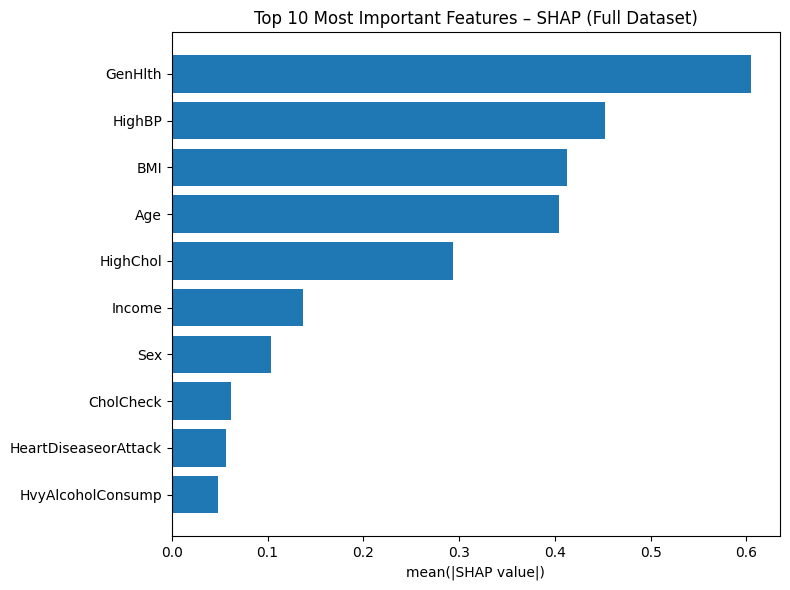

In [14]:
top10 = shap_imp.head(10)

plt.figure(figsize=(8,6))
plt.barh(top10["feature"][::-1], top10["mean_abs_shap"][::-1])
plt.xlabel("mean(|SHAP value|)")
plt.title("Top 10 Most Important Features – SHAP (Full Dataset)")
plt.tight_layout()
plt.show()


In [15]:
import numpy as np
import shap

# load shap matrix
data = np.load("/content/models_tuned/shap_full/shap_full_dataset.npy.npz")
shap_full = data["shap"]

# load feature matrix again
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)
X = df.drop(columns=["Diabetes_012","Diabetes_binary"])


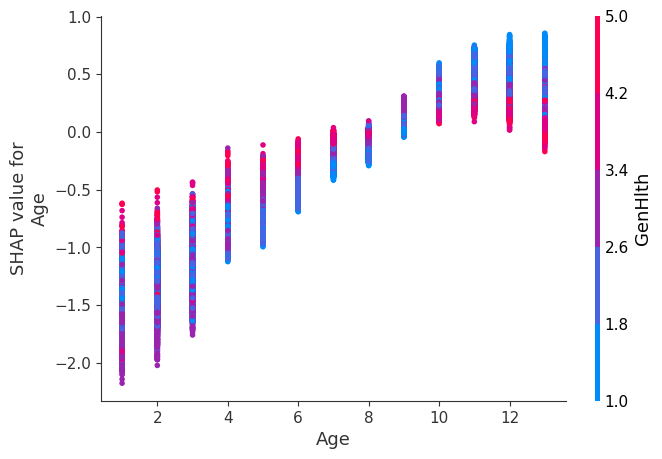

In [16]:
feature = shap_imp["feature"].iloc[3]   # change index 0,1,2...
shap.dependence_plot(
    feature, shap_full, X, show=True
)


In [17]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# Load full shap array
data = np.load("/content/models_tuned/shap_full/shap_full_dataset.npy.npz")
shap_full = data["shap"]

# Load X again
df = pd.read_csv("/content/diabetes_012_health_indicators_BRFSS2015.csv")
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 1 if x in [1,2] else 0)
X = df.drop(columns=["Diabetes_012","Diabetes_binary"])

top5 = ["GenHlth","BMI","HighBP","Age","HighChol"]

for f in top5:
    shap.dependence_plot(f, shap_full, X, show=False)
    plt.title(f"SHAP Dependence Plot: {f}")
    plt.tight_layout()
    plt.savefig(f"/content/models_tuned/shap_full/dependence_{f}.png", dpi=200)
    plt.close()


In [18]:
# Multiclass EDA: 3-class (Diabetes_012)
# Run in Colab. Saves plots and tables to /content/multiclass_eda/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kruskal

plt.style.use('seaborn-v0_8-whitegrid')

# -----------------------------
OUT = Path("/content/multiclass_eda")
(OUT).mkdir(exist_ok=True)
(OUT/"plots").mkdir(exist_ok=True)
(OUT/"tables").mkdir(exist_ok=True)

# -----------------------------
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
df = pd.read_csv(DATA_PATH)

# Ensure original 3-class target present
if "Diabetes_012" not in df.columns:
    raise ValueError("Diabetes_012 column not found")

# Basic class distribution
class_counts = df["Diabetes_012"].value_counts().sort_index()
class_props = df["Diabetes_012"].value_counts(normalize=True).sort_index()
class_dist_df = pd.DataFrame({"count": class_counts, "proportion": class_props})
class_dist_df.to_csv(OUT/"tables/class_distribution.csv")
print("Class distribution:")
print(class_dist_df)
print()

# -----------------------------
# Define variable groups
# -----------------------------
continuous_feats = ["Age", "BMI", "GenHlth", "PhysHlth", "MentHlth", "DiffWalk"]
categorical_feats = [
    "HighBP","HighChol","CholCheck","Smoker","Stroke","HeartDiseaseorAttack",
    "PhysActivity","Fruits","Veggies","HvyAlcoholConsump","AnyHealthcare","NoDocbcCost",
    "Sex","Education","Income"
]

# sanitize: keep only features present
continuous_feats = [f for f in continuous_feats if f in df.columns]
categorical_feats = [f for f in categorical_feats if f in df.columns]

# -----------------------------
# 1) Summary statistics by class (mean, median, std) for continuous features
# -----------------------------
grp = df.groupby("Diabetes_012")
means = grp[continuous_feats].mean().T
medians = grp[continuous_feats].median().T
stds = grp[continuous_feats].std().T

means.to_csv(OUT/"tables/continuous_means_by_class.csv")
medians.to_csv(OUT/"tables/continuous_medians_by_class.csv")
stds.to_csv(OUT/"tables/continuous_stds_by_class.csv")

# Print a compact summary
print("Continuous feature means by class (saved to tables):")
print(means)
print()

# -----------------------------
# 2) Boxplots for continuous features by class
# -----------------------------
for feat in continuous_feats:
    plt.figure(figsize=(7,5))
    order = sorted(df["Diabetes_012"].unique())
    sns.boxplot(x="Diabetes_012", y=feat, data=df, order=order)
    plt.title(f"Boxplot of {feat} by Diabetes_012")
    plt.xlabel("Diabetes_012 (0=no, 1=prediabetes, 2=diabetes)")
    plt.ylabel(feat)
    plt.tight_layout()
    plt.savefig(OUT/f"plots/box_{feat}_by_class.png", dpi=150)
    plt.close()

# -----------------------------
# 3) Countplots / stacked bars for categorical features
#    Save both counts and normalized (proportions) tables
# -----------------------------
for feat in categorical_feats:
    # counts by class
    ct = pd.crosstab(df[feat], df["Diabetes_012"])
    ct.to_csv(OUT/f"tables/counts_{feat}_by_class.csv")
    # normalized (rows)
    pct = pd.crosstab(df[feat], df["Diabetes_012"], normalize='index')
    pct.to_csv(OUT/f"tables/pct_{feat}_by_class.csv")

    # plot grouped bar chart for each category value
    plt.figure(figsize=(8,4))
    ct.plot(kind='bar', stacked=False, legend=True)
    plt.title(f"{feat} by Diabetes_012 (counts)")
    plt.xlabel(feat)
    plt.ylabel("count")
    plt.legend(title="Diabetes_012", loc="upper right")
    plt.tight_layout()
    plt.savefig(OUT/f"plots/bar_{feat}_by_class_counts.png", dpi=150)
    plt.close()

# -----------------------------
# 4) Statistical test: Kruskal-Wallis (nonparametric) for continuous features
#    Tests whether distributions differ across the 3 groups
# -----------------------------
kw_results = []
for feat in continuous_feats:
    groups = [group[feat].values for name, group in grp]
    try:
        stat, p = kruskal(*groups)
    except Exception as e:
        stat, p = np.nan, np.nan
    kw_results.append({"feature": feat, "kw_stat": stat, "p_value": p})

kw_df = pd.DataFrame(kw_results).sort_values("p_value")
kw_df.to_csv(OUT/"tables/kruskal_wallis_continuous.csv", index=False)
print("Kruskal-Wallis results saved to tables/kruskal_wallis_continuous.csv")
print(kw_df)
print()

# -----------------------------
# 5) For categorical features do Chi-square style check (Cramer's V)
#    We'll compute chi2 and Cramer's V for each categorical feature vs Diabetes_012
# -----------------------------
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # bias correction:
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min(rcorr-1, kcorr-1) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_stats = []
for feat in categorical_feats:
    ct = pd.crosstab(df[feat], df["Diabetes_012"])
    try:
        chi2, p, dof, expected = chi2_contingency(ct)
        cv = cramers_v(ct)
    except Exception as e:
        chi2, p, dof, cv = np.nan, np.nan, np.nan, np.nan
    cat_stats.append({"feature": feat, "chi2": chi2, "p_value": p, "cramers_v": cv})

cat_df = pd.DataFrame(cat_stats).sort_values("cramers_v", ascending=False)
cat_df.to_csv(OUT/"tables/categorical_chi2_cramersv.csv", index=False)
print("Categorical association results saved to tables/categorical_chi2_cramersv.csv")
print(cat_df)
print()

# -----------------------------
# 6) Save a compact summary that ranks features by importance (use previous SHAP if available)
# -----------------------------
# If SHAP mean abs exists from earlier full analysis, copy it
shap_path = Path("/content/models_tuned/shap_full/shap_mean_abs_full_dataset.csv")
if shap_path.exists():
    shap_df = pd.read_csv(shap_path)
    shap_df.to_csv(OUT/"tables/shap_mean_abs_full_dataset_copy.csv", index=False)
    print("Copied global SHAP importance to tables for reference")

# -----------------------------
print("Multiclass EDA complete. Plots and tables saved under:", OUT)


Class distribution:
               count  proportion
Diabetes_012                    
0             213703    0.842412
1               4631    0.018255
2              35346    0.139333

Continuous feature means by class (saved to tables):
Diabetes_012          0          1          2
Age            7.786559   9.083351   9.379053
BMI           27.742521  30.724466  31.944011
GenHlth        2.372391   2.975599   3.290981
PhysHlth       3.582416   6.348305   7.954479
MentHlth       2.944404   4.529907   4.461806
DiffWalk       0.132282   0.277478   0.371216

Kruskal-Wallis results saved to tables/kruskal_wallis_continuous.csv
    feature       kw_stat        p_value
0       Age   8811.762696   0.000000e+00
1       BMI  14130.749997   0.000000e+00
2   GenHlth  22480.925024   0.000000e+00
3  PhysHlth   6661.878029   0.000000e+00
5  DiffWalk  12776.891523   0.000000e+00
4  MentHlth    528.910573  1.407759e-115

Categorical association results saved to tables/categorical_chi2_cramersv.csv
   

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

...

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

In [20]:
# FINAL FIXED CELL: use xgboost.train() with early_stopping_rounds to avoid sklearn-wrapper API issues.
# Paste & run in your Colab cell.

import time, os, json
t0_all = time.time()

import numpy as np, pandas as pd, joblib
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
import xgboost as xgb

# ---- User settings ----
DATA_PATH = "/content/diabetes_012_health_indicators_BRFSS2015.csv"
OUT = Path("/content/multiclass_fast_outputs")
OUT.mkdir(exist_ok=True)
(OUT/"plots").mkdir(exist_ok=True)
(OUT/"tables").mkdir(exist_ok=True)

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
FINAL_N_ESTIMATORS_XGB = 150
FINAL_N_ESTIMATORS_RF  = 150
RF_N_ITER = 6
VERBOSE = 2

print("xgboost version:", xgb.__version__)

# ---- ALWAYS re-load and split for multiclass here to ensure correct target ----
print("Loading & splitting dataset for multiclass task.")
df = pd.read_csv(DATA_PATH)
if "Diabetes_012" not in df.columns:
    raise ValueError("Dataset must contain 'Diabetes_012'.")
# Drop both potential target columns from features if they exist
X = df.drop(columns=["Diabetes_012", "Diabetes_binary"], errors='ignore')
y = df["Diabetes_012"].copy()
classes = np.unique(y)
n_classes = len(classes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("n_classes:", n_classes)

# helpers
def save_cm(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred)
    pd.DataFrame(cm).to_csv(OUT/f"tables/{name}_confusion_matrix.csv", index=False)

def multiclass_roc_plot(probs_dict, y_test, out_path):
    y_test_bin = label_binarize(y_test, classes=classes)
    plt.figure(figsize=(8,6))
    for name, probs in probs_dict.items():
        fpr = dict(); tpr = dict()
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(n_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= n_classes
        macro_auc = auc(all_fpr, mean_tpr)
        plt.plot(all_fpr, mean_tpr, label=f"{name} (macro AUC={macro_auc:.3f})")
    plt.plot([0,1],[0,1], linestyle='--', color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC (macro-average OvR)")
    plt.legend(loc="lower right"); plt.tight_layout()
    plt.savefig(out_path, dpi=150); plt.close()

# ---- If xgb_search exists, capture best params, else defaults ----
if "xgb_search" in globals():
    print("Using xgb_search.best_params_.")
    best_params_sklearn = xgb_search.best_params_.copy()
else:
    print("No xgb_search found; using defaults for xgboost.")
    best_params_sklearn = {
        "n_estimators": 150,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "gamma": 0,
        "reg_alpha": 0,
        "reg_lambda": 1
    }

# Translate sklearn-style best_params into xgboost.train params
# map: learning_rate -> eta ; reg_alpha -> alpha ; reg_lambda -> lambda
xgb_params = {
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eta": best_params_sklearn.get("learning_rate", best_params_sklearn.get("eta", 0.03)),
    "max_depth": int(best_params_sklearn.get("max_depth", 4)),
    "subsample": float(best_params_sklearn.get("subsample", 0.8)),
    "colsample_bytree": float(best_params_sklearn.get("colsample_bytree", 0.8)),
    "gamma": float(best_params_sklearn.get("gamma", 0)),
    "alpha": float(best_params_sklearn.get("reg_alpha", 0)),
    "lambda": float(best_params_sklearn.get("reg_lambda", 1)),
    "verbosity": 0,
    "seed": RANDOM_STATE,
    "nthread": 1   # keep single-threaded for stability inside Colab
}

print("xgb.train params preview:", {k:xgb_params[k] for k in ["eta","max_depth","subsample","colsample_bytree"]})

# Prepare DMatrix and do early-stopping training using xgb.train
X_tr_fit, X_tr_val, y_tr_fit, y_tr_val = train_test_split(X_train, y_train, test_size=0.10, stratify=y_train, random_state=RANDOM_STATE)
dtrain = xgb.DMatrix(X_tr_fit.values, label=y_tr_fit.values)
dval   = xgb.DMatrix(X_tr_val.values, label=y_tr_val.values)
dtest  = xgb.DMatrix(X_test.values)

num_boost_round = FINAL_N_ESTIMATORS_XGB
early_stopping_rounds = 15

print("Training xgboost via xgb.train() with early stopping ...")
t0 = time.time()
bst = xgb.train(
    params=xgb_params,
    dtrain=dtrain,
    num_boost_round=num_boost_round,
    evals=[(dval, "validation")],
    early_stopping_rounds=early_stopping_rounds,
    verbose_eval=False
)
print("xgboost.train finished in {:.1f}s. Best iteration: {}".format(time.time()-t0, bst.best_iteration))

# Predict probabilities and evaluate
xgb_raw_pred = bst.predict(dtest)  # shape (n_samples, n_classes)
# ensure shape is (n_samples, n_classes)
if xgb_raw_pred.ndim == 1:
    # unlikely for multiclass, but handle
    xgb_prob = xgb_raw_pred.reshape(-1, n_classes)
else:
    xgb_prob = xgb_raw_pred

xgb_pred = np.argmax(xgb_prob, axis=1)
xgb_auc_macro = roc_auc_score(y_test, xgb_prob, multi_class='ovr', average='macro')
print("XGBoost macro AUC (train via xgb.train):", xgb_auc_macro)

# save model
bst.save_model(str(OUT/"xgb_tuned_bst.model"))
# Optionally save as sklearn-compatible booster via joblib? Not necessary; bst.save_model is fine.

with open(OUT/"tables/xgb_report_train_via_bst.json","w") as f:
    json.dump(classification_report(y_test, xgb_pred, output_dict=True), f, indent=2)
save_cm(y_test, xgb_pred, "xgb_bst")

# ---- RandomForest short search & refit ----
print("\nRandomForest: short RandomizedSearch and final refit")
rf_base = RandomForestClassifier(n_jobs=1, class_weight='balanced', random_state=RANDOM_STATE)
rf_param_dist = {
    "n_estimators": [100,150,200],
    "max_depth": [None,10,20],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4],
    "max_features": ['sqrt','log2',0.5]
}
rf_search = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=RF_N_ITER, scoring='roc_auc_ovr', n_jobs=-1, cv=CV, verbose=VERBOSE, random_state=RANDOM_STATE, return_train_score=False)
t0 = time.time()
rf_search.fit(X_train, y_train)
print("RandomForest search time: {:.1f}s".format(time.time()-t0))
print("Best RF params:", rf_search.best_params_)

rf_best = rf_search.best_estimator_
rf_best.set_params(n_estimators=FINAL_N_ESTIMATORS_RF, n_jobs=-1)
t0 = time.time()
rf_best.fit(X_train, y_train)
print("RF final refit time: {:.1f}s".format(time.time() - t0))

rf_prob = rf_best.predict_proba(X_test)
rf_pred = rf_best.predict(X_test)
rf_auc_macro = roc_auc_score(y_test, rf_prob, multi_class='ovr', average='macro')
print("RandomForest macro AUC:", rf_auc_macro)
joblib.dump(rf_best, OUT/"rf_tuned_final.pkl")
with open(OUT/"tables/rf_report.json","w") as f:
    json.dump(classification_report(y_test, rf_pred, output_dict=True), f, indent=2)
save_cm(y_test, rf_pred, "rf_tuned_final")

# ---- LinearSVC calibrated (if not already present) ----
if "cal_svc" not in globals():
    print("\nTraining calibrated LinearSVC (fast)...")
    svc_pipe = Pipeline([("scaler", StandardScaler()), ("lin", LinearSVC(class_weight='balanced', dual=False, max_iter=5000, random_state=RANDOM_STATE))])
    cal_svc = CalibratedClassifierCV(estimator=svc_pipe, method='sigmoid', cv=3)
    cal_svc.fit(X_train, y_train)
    joblib.dump(cal_svc, OUT/"linear_svc_calibrated.pkl")
else:
    print("\nUsing existing calibrated LinearSVC from session.")

svc_prob = cal_svc.predict_proba(X_test)
svc_pred = cal_svc.predict(X_test)
svc_auc_macro = roc_auc_score(y_test, svc_prob, multi_class='ovr', average='macro')
with open(OUT/"tables/linear_svc_report.json","w") as f:
    json.dump(classification_report(y_test, svc_pred, output_dict=True), f, indent=2)
save_cm(y_test, svc_pred, "linear_svc")

# ---- Summaries, ROC plot, save predictions ----
print("\nFinal macro AUCs:")
print("LinearSVC:", round(svc_auc_macro,4))
print("XGBoost (bst):", round(xgb_auc_macro,4))
print("RandomForest:", round(rf_auc_macro,4))

pd.DataFrame([
    {"model":"LinearSVC_calibrated","roc_auc_macro":svc_auc_macro},
    {"model":"XGB_bst","roc_auc_macro":xgb_auc_macro},
    {"model":"RF_tuned","roc_auc_macro":rf_auc_macro}
]).to_csv(OUT/"tables/auc_summary_multiclass.csv", index=False)

multiclass_roc_plot({"LinearSVC":svc_prob, "XGB_bst":xgb_prob, "RF":rf_prob}, y_test, OUT/"plots/multiclass_macro_roc_bst.png")

preds_df = pd.DataFrame({"y_true": y_test.values, "svc_pred": svc_pred, "xgb_pred": xgb_pred, "rf_pred": rf_pred})
for i in range(n_classes):
    preds_df[f"svc_prob_{i}"] = svc_prob[:,i]
    preds_df[f"xgb_prob_{i}"] = xgb_prob[:,i]
    preds_df[f"rf_prob_{i}"]  = rf_prob[:,i]
preds_df.to_csv(OUT/"tables/multiclass_predictions_test_bst.csv", index=False)

print("\nAll outputs saved to:", OUT)
print("Total elapsed time (s):", round(time.time() - t0_all,1))


xgboost version: 3.1.2
Loading & splitting dataset for multiclass task.
n_classes: 3
No xgb_search found; using defaults for xgboost.
xgb.train params preview: {'eta': 0.03, 'max_depth': 4, 'subsample': 0.8, 'colsample_bytree': 0.8}
Training xgboost via xgb.train() with early stopping ...
xgboost.train finished in 6.4s. Best iteration: 149
XGBoost macro AUC (train via xgb.train): 0.7850897149771813

RandomForest: short RandomizedSearch and final refit
Fitting 3 folds for each of 6 candidates, totalling 18 fits
RandomForest search time: 362.0s
Best RF params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 10}
RF final refit time: 24.6s
RandomForest macro AUC: 0.7642762961007775

Training calibrated LinearSVC (fast)...

Final macro AUCs:
LinearSVC: 0.7811
XGBoost (bst): 0.7851
RandomForest: 0.7643

All outputs saved to: /content/multiclass_fast_outputs
Total elapsed time (s): 399.9
